In [41]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


In [42]:
# Set your data directory and file path
data_dir = os.getenv('DATA_DIR')
signal_file = os.path.join(data_dir, 'MCP/withamp/wave_0.txt')

# Functions
def read_file (filename):
    events = {}

    with open(filename, 'r') as file:
        while True:
            # Read headers
            header_lines = [file.readline().strip() for _ in range(8)]
            if not header_lines[0]:
                break

            # Extract the header information
            record_length = int(header_lines[0].split(":")[1])
            board_id = int(header_lines[1].split(":")[1])
            event_number = int(header_lines[3].split(":")[1])
            if event_number == 0: # Because for some reason it changes after 1st event.
                channel = str(str(header_lines[2].split(":")[1].strip()))
                print(f"Reading channel: {channel}")
            else:
                channel = channel
            pattern = int(header_lines[4].split(":")[1], 16)
            trigger_time_stamp = int(header_lines[5].split(":")[1])
            dc_offset = int(header_lines[6].split(":")[1], 16)
            start_index_cell = int(header_lines[7].split(":")[1])

            # Read the sample points
            samples = []
            for _ in range(record_length):
                sample = file.readline().strip()
                if sample:
                    samples.append(float(sample))
            samples = np.array(samples)

            # process
            bg = np.mean(samples[:20])
            samples = samples-bg
            if channel != 'TR_0_0':
                samples = samples*-1
            max_value = np.max(samples)
            dx = 200e-12 #spacing of the data points
            integral = np.trapz(samples[samples > 0], dx=dx)

            event = {
                #'RecordLength': record_length,
                #'BoardID': board_id,
                #'Channel': channel,
                #'EventNumber': event_number,
                #'Pattern': pattern,
                #'TriggerTimeStamp': trigger_time_stamp,
                #'DCOffset': dc_offset,
                #'StartIndexCell': start_index_cell,
                f'Samples.Ch{channel}': np.array(samples),
                f'Background.Ch{channel}': bg,
                f'Max_value.Ch{channel}' : max_value,
                f'Integral.Ch{channel}' : integral,
            }
                                
            events[event_number] = event
    df = pd.DataFrame.from_dict(events, orient='index')# Transpose the DataFrame so that each row is an event

    return df

In [43]:
df = read_file(signal_file)
trig_df = read_file(os.path.join(data_dir, 'MCP/withamp/TR_0_0.txt'))

Reading channel: 0
Reading channel: TR_0_0


In [50]:
merged_df = pd.concat([df, trig_df], axis=1)

Percentage of good signals: 16.85188043422339 %


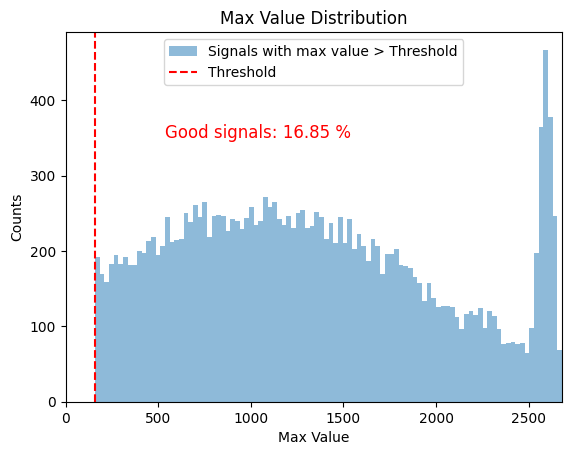

In [51]:
filter_good_signal = 159
df_goodsignal = merged_df[merged_df['Max_value.Ch0'] > filter_good_signal]

# Plotting

frac_good = len(df_goodsignal)/len(df)*100
print(f"Percentage of good signals: {frac_good} %")
x_max = 2678

plt.hist(df_goodsignal['Max_value.Ch0'], bins=100, alpha=0.5, label='Signals with max value > Threshold')

# add a vertical line at the threshold
plt.axvline(x=filter_good_signal, color='r', linestyle='--', label='Threshold')
plt.xlim(0, x_max)
plt.xlabel('Max Value')
plt.ylabel('Counts')
plt.title('Max Value Distribution')
plt.legend()

# add some text annotation showing the percentage of good signals
plt.text(0.2*x_max, 350, f'Good signals: {frac_good:.2f} %', fontsize=12, color='r')

plt.show()







In [55]:
df_goodsignal

,Samples.Ch0,Background.Ch0,Max_value.Ch0,Integral.Ch0,Samples.ChTR_0_0,Background.ChTR_0_0,Max_value.ChTR_0_0,Integral.ChTR_0_0
0,"[7.135937500000182, 7.135937500000182, 2.17670...",2588.135938,1654.804151,0.000004,"[-1.201248899999996, -1.201248899999996, 1.774...",103.201249,3997.809981,0.000665
8,"[3.756970249999995, 3.756970249999995, -0.2076...",2538.756970,709.001111,0.000002,"[-3.2824344499999825, -3.2824344499999825, -6....",67.282434,4085.072546,0.000664
15,"[-6.002465900000061, -6.003197900000032, -6.99...",2551.997534,1434.146582,0.000003,"[-5.249081950000004, -5.242817950000003, 4.740...",71.249082,4065.220156,0.000648
18,"[5.474133199999869, 5.474133199999869, 6.45972...",2581.474133,1268.355725,0.000003,"[0.30884884999998974, 0.30884884999998974, 5.2...",67.691151,4024.879650,0.000663
20,"[1.770214949999172, 1.770214949999172, -2.1555...",2565.770215,1216.472852,0.000003,"[1.5417659499999985, 1.5417659499999985, -6.30...",69.458234,4091.234149,0.000661
...,...,...,...,...,...,...,...,...
116587,"[16.208923299999697, 16.221130299999913, 17.10...",2573.208923,656.827819,0.000002,"[4.906914499999999, 4.808502500000003, -3.1432...",102.093086,4020.620293,0.000644
116612,"[1.915795899999921, 1.915795899999921, 8.90529...",2605.915796,1928.503748,0.000008,"[-5.2969487000000015, -5.2969487000000015, -7....",96.296949,4042.838305,0.000656
116613,"[-0.6225219999996625, -0.6042109999998502, 2.3...",2593.377478,1174.330359,0.000002,"[17.339564100000004, 17.2600281, 4.16723110000...",100.660436,4027.175990,0.000669
116615,"[-4.373217699999714, -4.381274699999722, -9.37...",2598.626782,804.667553,0.000002,"[6.498478649999996, 6.490376650000002, 1.52502...",104.501521,4057.301702,0.000652


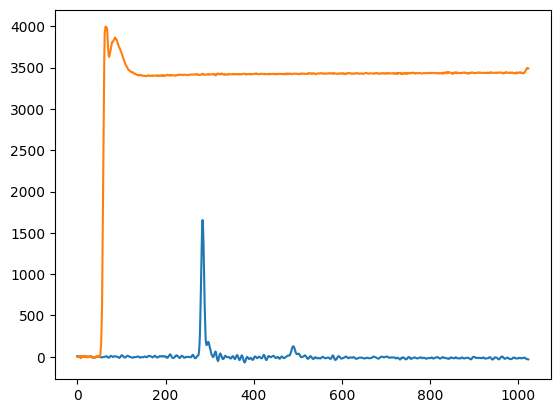

In [57]:
plt.plot(df_goodsignal['Samples.Ch0'].iloc[0], label='Good Signal')
plt.plot(df_goodsignal['Samples.ChTR_0_0'].iloc[0], label='Trigger Signal')

In [59]:
filter_events_min = 200
filter_events_max = 2500

df_middle_events = df_goodsignal[(df_goodsignal['Max_value.Ch0'] > filter_events_min) & (df_goodsignal['Max_value.Ch0'] < filter_events_max)]
df_high_events = df_goodsignal[df_goodsignal['Max_value.Ch0'] > filter_events_max]

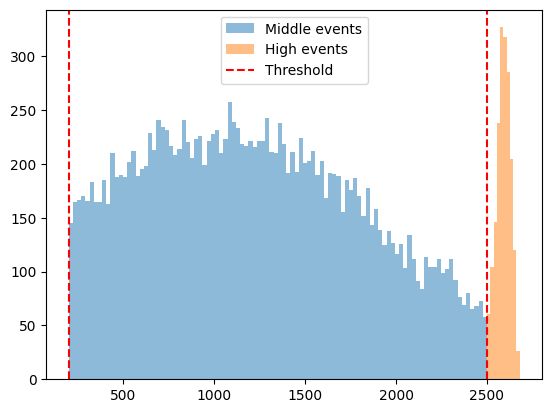

In [60]:
plt.hist(df_middle_events['Max_value.Ch0'], bins=100, alpha=0.5, label='Middle events')
plt.hist(df_high_events['Max_value.Ch0'], bins=10, alpha=0.5, label='High events')
plt.axvline(x=filter_events_min, color='r', linestyle='--', label='Threshold')
plt.axvline(x=filter_events_max, color='r', linestyle='--')
plt.legend()
plt.show()

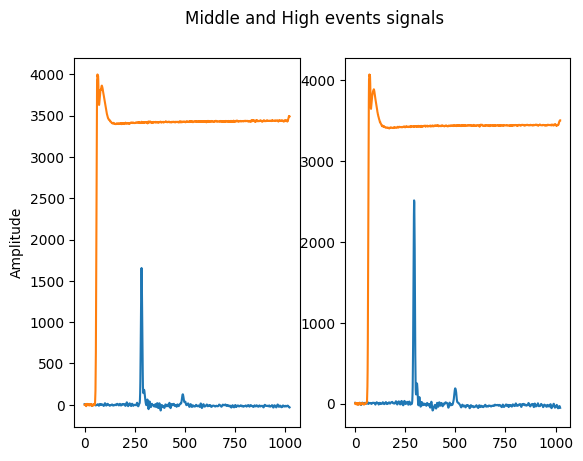

In [64]:
# plot an example of a signal from middle and high events next to each other
plt.subplot(1, 2, 1)
plt.plot(df_middle_events['Samples.Ch0'].iloc[0], label='Middle event')
plt.plot(df_middle_events['Samples.ChTR_0_0'].iloc[0], label='Trigger Signal')
plt.ylabel('Amplitude')
plt.subplot(1, 2, 2)
plt.plot(df_high_events['Samples.Ch0'].iloc[0], label='High event')
plt.plot(df_high_events['Samples.ChTR_0_0'].iloc[0], label='Trigger Signal')

# add a title to the whole canvas
plt.suptitle('Middle and High events signals')
plt.show()


<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_44936/1306017834.py:83: SyntaxWarning: invalid escape sequence '\m'
  plt.text(46, 100, f'$\mu$ = {popt[1]:.2f} ns\n$\sigma$ = {popt[2]:.2f} ns', fontsize=12, color='r')
/tmp/ipykernel_44936/1306017834.py:83: SyntaxWarning: invalid escape sequence '\s'
  plt.text(46, 100, f'$\mu$ = {popt[1]:.2f} ns\n$\sigma$ = {popt[2]:.2f} ns', fontsize=12, color='r')


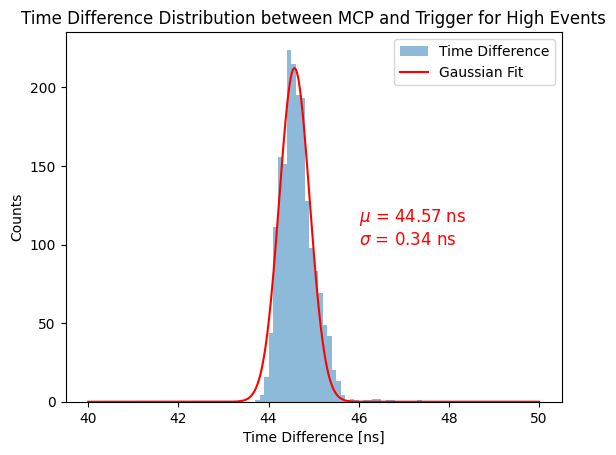

In [100]:
# Set threshold fraction
threshold_fraction = 0.4

# Create lists to store the calculated times for each event
trig_times = []
mcp_times = []

# Iterate over each event in the dataframe
for index, row in df_high_events.iterrows():
    # Extract the trigger and MCP signals
    trig_signal = row['Samples.ChTR_0_0']
    mcp_signal = row['Samples.Ch0']

    # Normalize the MCP signal by subtracting the minimum value
    mcp_signal = mcp_signal - np.min(mcp_signal)

    # Define the threshold values
    trig_threshold = threshold_fraction * np.max(trig_signal)
    mcp_threshold = threshold_fraction * np.max(mcp_signal)

    # Find indices where signals cross their respective thresholds
    trig_indices = np.where(trig_signal > trig_threshold)[0]
    mcp_indices = np.where(mcp_signal > mcp_threshold)[0]

    # Interpolate to find exact crossing time if indices are found
    if len(trig_indices) > 0:
        trig_index = trig_indices[0]
        trig_time = trig_index + (trig_threshold - trig_signal[trig_index-1]) / (trig_signal[trig_index] - trig_signal[trig_index-1])
    else:
        trig_time = np.nan  # Assign NaN if no crossing is found

    if len(mcp_indices) > 0:
        mcp_index = mcp_indices[0]
        mcp_time = mcp_index + (mcp_threshold - mcp_signal[mcp_index-1]) / (mcp_signal[mcp_index] - mcp_signal[mcp_index-1])
    else:
        mcp_time = np.nan  # Assign NaN if no crossing is found

    # Append the times to the respective lists
    trig_times.append(trig_time)
    mcp_times.append(mcp_time)

# Create a new DataFrame to store the times
times_df = pd.DataFrame({
    'Event_Index': range(len(trig_times)),
    'Trigger_Time': trig_times,
    'MCP_Time': mcp_times
})

# conversion factor from time index to time in picoseconds: rate of 5 GHz i.e. 1 sample is 200 ps

time_conversion = 200e-3 # ps

# Convert the time indices to actual times in seconds
times_df['Trigger_Time'] = times_df['Trigger_Time'] * time_conversion
times_df['MCP_Time'] = times_df['MCP_Time'] * time_conversion


# fit a gaussian to the data
from scipy.optimize import curve_fit
from scipy.stats import norm

# Define the Gaussian function
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit the Gaussian function to the data
counts, bins = np.histogram(times_df['MCP_Time']-times_df['Trigger_Time'], bins=100, range=(40, 50))
bin_centers = (bins[:-1] + bins[1:]) / 2
popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[1, 45, 1])

# Plot the histogram
plt.hist(times_df['MCP_Time']-times_df['Trigger_Time'], bins=100, alpha=0.5, label='Time Difference', range=(40, 50))

# Plot the fitted Gaussian
x = np.linspace(40, 50, 1000)
plt.plot(x, gaussian(x, *popt), 'r-', label='Gaussian Fit')

plt.xlabel('Time Difference [ns]')
plt.ylabel('Counts')
plt.legend()

# Add a text annotation showing the fitted parameters
plt.text(46, 100, f'$\mu$ = {popt[1]:.2f} ns\n$\sigma$ = {popt[2]:.2f} ns', fontsize=12, color='r')

plt.title('Time Difference Distribution between MCP and Trigger for High Events') 

plt.show()



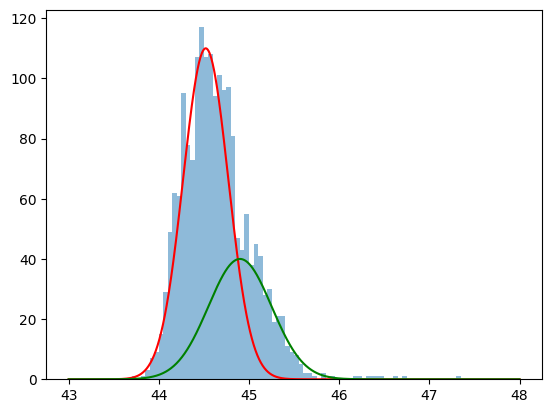

In [152]:
plt.hist(times_df['MCP_Time']-times_df['Trigger_Time'], bins=100, alpha=0.5, label='Time Difference', range=(43, 48))

# plot a gaussian 

# Define the Gaussian function
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))
x = np.linspace(43, 48, 1000)

a = 110
mu = 44.52
sigma = 0.25

plt.plot(x, gaussian(x, a, mu, sigma), 'r-', label='Gaussian Fit')

a = 40
mu = 44.9
sigma = 0.35

plt.plot(x, gaussian(x, a, mu, sigma), 'g-', label='Gaussian Fit')


